# 🔀 Crime Hotspot — Hybrid ConvLSTM-STGAT with Autoregressive Self-Training

**Standalone Colab notebook — mounts Drive, trains, evaluates.**

## Architecture overview
```
ConvLSTM Branch (grid path)          STGAT Branch (graph path)
  (B, T, 1, H, W)                      (B, T, N, IN_CH)
        │                                      │
  ConvLSTMCell ×2                    GATConv ×2 (per timestep)
  ──────────────                     ──────────────────────────
  final hidden h                     GAT embeddings (SEQ_LEN steps)
  (B, Hc, H, W)                              │
        │                              GRU (per node)
  reshape → (B, N, Hc)                       │
        └──────────┐         ┌────────────── ┘
                   ▼         ▼
              Concatenate (B, N, Hc + Hg)
                        │
                 Fusion MLP
                        │
                   Logits (B, N)
```

## Autoregressive Self-Training (two-phase)
1. **Phase 1** — Standard supervised training on Chicago ground-truth labels
2. **Prediction pass** — Run Phase-1 model over the *training set* to collect soft pseudo-labels
3. **Phase 2** — Re-train with a mixed target:
   `y_mixed = (1 − α) · y_hard  +  α · y_pseudo`
   The model learns from its own predicted distribution, sharpening confidence on
   ambiguous cells and improving calibration without any extra labelled data.

## What gets saved
```
models/hybrid_convlstm_stgat.pt
outputs/calibration/hybrid/
outputs/hybrid/chicago/
outputs/hybrid/crosscity/
outputs/hybrid/tables/
```


## 📁 STEP 1 — Mount Drive & Install Dependencies

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import subprocess
subprocess.run(['pip', 'install', '-q', 'torch_geometric'], check=True)
subprocess.run(['pip', 'install', '-q',
                'pyg_lib', 'torch_scatter', 'torch_sparse',
                '-f', 'https://data.pyg.org/whl/torch-2.1.0+cu121.html'],
               check=False)
subprocess.run(['pip', 'install', '-q', 'sympy==1.13.1'], check=True)

import os, json, warnings
import numpy  as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import joblib
warnings.filterwarnings('ignore')

BASE_DIR  = '/content/drive/MyDrive/CrimeHotspot'
PROC_DIR  = f'{BASE_DIR}/data/processed'
MODEL_DIR = f'{BASE_DIR}/models'
CAL_DIR   = f'{BASE_DIR}/outputs/calibration/hybrid'
OUT_DIR   = f'{BASE_DIR}/outputs/hybrid'

for d in [MODEL_DIR, CAL_DIR,
          f'{OUT_DIR}/chicago', f'{OUT_DIR}/crosscity', f'{OUT_DIR}/tables']:
    os.makedirs(d, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device  : {DEVICE}')
print(f'Outputs : {OUT_DIR}')
print('✅ Setup complete')


Mounted at /content/drive
Device  : cuda
Outputs : /content/drive/MyDrive/CrimeHotspot/outputs/hybrid
✅ Setup complete


## 📂 STEP 2 — Load Config, Data & Build Splits

In [2]:
with open(f'{PROC_DIR}/config.json') as f:
    cfg = json.load(f)

CELL_SIZE            = cfg['CELL_SIZE']
LAT_MIN, LAT_MAX     = cfg['LAT_MIN'], cfg['LAT_MAX']
LON_MIN, LON_MAX     = cfg['LON_MIN'], cfg['LON_MAX']
GRID_ROWS, GRID_COLS = cfg['GRID_ROWS'], cfg['GRID_COLS']
SEQ_LEN              = cfg['SEQ_LEN']

print('Loading data...')
daily       = pd.read_csv(f'{PROC_DIR}/daily_features.csv', parse_dates=['date_day'])
cell_index  = pd.read_csv(f'{PROC_DIR}/cell_index.csv')
grid_tensor = np.load(f'{PROC_DIR}/grid_tensor.npy')

_, H, W   = grid_tensor.shape
N         = H * W
T_total   = grid_tensor.shape[0]

split_t   = int(T_total * 0.80)
cal_split = int(split_t  * 0.85)

print(f'Grid tensor   : {grid_tensor.shape}  (days × {H} × {W})')
print(f'Nodes (H×W)   : {N}')
print(f'Train days    : 0 → {split_t}')
print(f'Cal days      : {cal_split} → {split_t}')
print(f'Test days     : {split_t} → {T_total}')
print(f'SEQ_LEN       : {SEQ_LEN}')
print('✅ Data loaded')


Loading data...
Grid tensor   : (1547, 85, 86)  (days × 85 × 86)
Nodes (H×W)   : 7310
Train days    : 0 → 1237
Cal days      : 1051 → 1237
Test days     : 1237 → 1547
SEQ_LEN       : 7
✅ Data loaded


## ⚙️ STEP 3 — Metric Helpers & Calibration Utilities

In [3]:
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    accuracy_score, average_precision_score,
    precision_recall_curve, roc_curve
)
from sklearn.linear_model import LogisticRegression as _LR
from scipy.optimize       import minimize_scalar
from scipy.special        import expit as scipy_expit

def compute_pai(y_true, y_proba, k):
    n_total   = len(y_true)
    n_hotspot = max(float(y_true.sum()), 1)
    k_        = min(k, n_total)
    topk      = np.argsort(y_proba)[-k_:]
    hits      = float(y_true[topk].sum())
    return round((hits / n_hotspot) / (k_ / n_total), 4)

def compute_metrics(y_true, y_proba, threshold=0.5):
    y_true  = np.array(y_true)
    y_proba = np.array(y_proba)
    y_pred  = (y_proba >= threshold).astype(int)
    m = {
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'AUROC'    : round(roc_auc_score(y_true, y_proba), 4),
        'AUPRC'    : round(average_precision_score(y_true, y_proba), 4),
        'F1'       : round(f1_score(y_true, y_pred, zero_division=0), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_true, y_pred, zero_division=0), 4),
    }
    for k in [50, 100, 200]:
        m[f'PAI@{k}'] = compute_pai(y_true, y_proba, k)
    return m

def platt_calibrate(y_cal_proba, y_cal_true, y_test_proba):
    platt = _LR(C=1.0, solver='lbfgs', max_iter=1000)
    platt.fit(y_cal_proba.reshape(-1, 1), y_cal_true)
    y_cal_cal  = platt.predict_proba(y_cal_proba.reshape(-1, 1))[:, 1]
    y_test_cal = platt.predict_proba(y_test_proba.reshape(-1, 1))[:, 1]
    prec, rec, th = precision_recall_curve(y_cal_true, y_cal_cal)
    f1s    = 2 * prec * rec / (prec + rec + 1e-9)
    best_t = float(th[np.argmax(f1s)])
    return y_test_cal, best_t, platt

def find_temperature(logits, y_true):
    def nll(T):
        p = scipy_expit(logits / T)
        p = np.clip(p, 1e-7, 1 - 1e-7)
        return -np.mean(y_true * np.log(p) + (1 - y_true) * np.log(1 - p))
    T_opt = minimize_scalar(nll, bounds=(0.1, 20.0), method='bounded').x
    return T_opt, scipy_expit(logits / T_opt)

print('✅ Metric helpers ready')


✅ Metric helpers ready


## 🕸️ STEP 4 — Build Spatial Graph & Static Node Features

In [4]:
from torch_geometric.nn import GATConv

# ── Queen-adjacency graph ─────────────────────────────────────────────────────
def build_queen_graph(H, W):
    src, dst = [], []
    for r in range(H):
        for c in range(W):
            node = r * W + c
            for dr in [-1, 0, 1]:
                for dc in [-1, 0, 1]:
                    if dr == 0 and dc == 0: continue
                    nr, nc = r + dr, c + dc
                    if 0 <= nr < H and 0 <= nc < W:
                        src.append(node); dst.append(nr * W + nc)
    return torch.tensor([src, dst], dtype=torch.long)

edge_index     = build_queen_graph(H, W)
edge_index_dev = edge_index.to(DEVICE)
print(f'Graph nodes : {N}  |  edges : {edge_index.shape[1]}')

# ── Static POI + KDE node features ───────────────────────────────────────────
STATIC_COLS = ['poi_bar', 'poi_school', 'poi_transit', 'poi_hospital', 'kde_density']

poi_per_cell = (
    daily.groupby('cell_id')[STATIC_COLS]
         .mean()
         .reindex(cell_index['cell_id'])
         .fillna(0)
)
poi_min  = poi_per_cell.min()
poi_max  = poi_per_cell.max()
poi_norm = (poi_per_cell - poi_min) / (poi_max - poi_min + 1e-9)
node_features = poi_norm.values.astype(np.float32)   # (N, 5)

IN_CH = 1 + node_features.shape[1]    # 1 dynamic + 5 static = 6
print(f'IN_CH : {IN_CH}  (1 dynamic crime count + 5 static POI/KDE)')
print('✅ Spatial graph & node features ready')


Graph nodes : 7310  |  edges : 57458
IN_CH : 6  (1 dynamic crime count + 5 static POI/KDE)
✅ Spatial graph & node features ready


## 🗂️ STEP 5 — Datasets & DataLoaders

In [5]:
class CrimeGraphDataset(Dataset):
    """
    Yields (x, y) where:
      x : (SEQ_LEN, N, IN_CH)  graph node sequences (dynamic + static)
      y : (N,)                 binary hotspot label per node for next day
    Also stores the raw grid slice so we can reconstruct (H, W) maps later.
    """
    def __init__(self, grid, seq_len, node_feats):
        self.grid       = grid
        self.seq_len    = seq_len
        self.node_feats = node_feats
        T, H_, W_       = grid.shape
        self.N          = H_ * W_
        self.H, self.W  = H_, W_

    def __len__(self):
        return len(self.grid) - self.seq_len

    def __getitem__(self, idx):
        x_dyn  = self.grid[idx : idx + self.seq_len].astype(np.float32)
        x_dyn  = x_dyn.reshape(self.seq_len, self.N, 1)
        max_c  = x_dyn.max() + 1e-9
        x_dyn /= max_c

        static = np.tile(self.node_feats[np.newaxis], (self.seq_len, 1, 1))
        x      = np.concatenate([x_dyn, static], axis=-1)   # (T, N, IN_CH)
        y      = (self.grid[idx + self.seq_len] > 0).astype(np.float32).reshape(self.N)

        return torch.tensor(x), torch.tensor(y)

train_ds = CrimeGraphDataset(grid_tensor[:split_t],            SEQ_LEN, node_features)
cal_ds   = CrimeGraphDataset(grid_tensor[cal_split:split_t],   SEQ_LEN, node_features)
test_ds  = CrimeGraphDataset(grid_tensor[split_t:],            SEQ_LEN, node_features)

train_dl = DataLoader(train_ds, batch_size=4, shuffle=True,  num_workers=2, pin_memory=True)
cal_dl   = DataLoader(cal_ds,   batch_size=4, shuffle=False, num_workers=2)
test_dl  = DataLoader(test_ds,  batch_size=4, shuffle=False, num_workers=2)

print(f'Train : {len(train_ds)} samples')
print(f'Cal   : {len(cal_ds)}   samples')
print(f'Test  : {len(test_ds)}  samples')
xb, yb = next(iter(train_dl))
print(f'Batch x : {xb.shape}   (B, T, N, IN_CH)')
print(f'Batch y : {yb.shape}   (B, N)')
print('✅ DataLoaders ready')


Train : 1230 samples
Cal   : 179   samples
Test  : 303  samples
Batch x : torch.Size([4, 7, 7310, 6])   (B, T, N, IN_CH)
Batch y : torch.Size([4, 7310])   (B, N)
✅ DataLoaders ready


## 🧠 STEP 6 — Hybrid ConvLSTM-STGAT Model

### Design rationale

| Component | Role |
|-----------|------|
| **ConvLSTM branch** | Captures *local* spatial patterns — nearby cells via sliding 3×3 convolution, temporal state via LSTM gates |
| **STGAT branch** | Captures *relational* patterns — learns *which* neighbours matter via attention; handles irregular connectivity |
| **Cross-attention fusion** | Lets each branch attend to the other's representations before merging, avoiding a naive concat |
| **Shared GRU** | A single temporal encoder reads the fused per-timestep features, reducing redundancy |

### Autoregressive self-training
After Phase 1 training the model collects its own soft predictions on the **training set**
and uses them as auxiliary supervision in Phase 2:

```
y_mixed = (1 − α) · y_hard  +  α · sigmoid(logit_phase1)
```

This is a form of **label smoothing driven by the model's own uncertainty** — high-confidence
cells stay sharp, uncertain cells get smoothed, which improves calibration and PAI@k.


In [12]:
import gc
import torch.nn.functional as F
from torch_geometric.nn import GATConv

# ── Free memory from any previous failed runs ─────────────────────────────────
try:
    del hybrid
except NameError:
    pass
gc.collect()
torch.cuda.empty_cache()
print(f'GPU free before build: '
      f'{torch.cuda.mem_get_info()[0]/1024**3:.2f} GB / '
      f'{torch.cuda.mem_get_info()[1]/1024**3:.2f} GB')

# ── ConvLSTM branch ───────────────────────────────────────────────────────────
class ConvLSTMCell(nn.Module):
    def __init__(self, in_ch, hid_ch, ks=3):
        super().__init__()
        self.hid_ch = hid_ch
        self.conv   = nn.Conv2d(in_ch + hid_ch, 4 * hid_ch, ks, padding=ks // 2)

    def forward(self, x, h, c):
        i, f, o, g = self.conv(torch.cat([x, h], dim=1)).chunk(4, dim=1)
        c = torch.sigmoid(f) * c + torch.sigmoid(i) * torch.tanh(g)
        h = torch.sigmoid(o) * torch.tanh(c)
        return h, c

    def init_hidden(self, B, H, W, device):
        return (torch.zeros(B, self.hid_ch, H, W, device=device),
                torch.zeros(B, self.hid_ch, H, W, device=device))


class ConvLSTMBranch(nn.Module):
    def __init__(self, in_ch=1, hid_ch=16):   # hid_ch 32→16
        super().__init__()
        self.cell1  = ConvLSTMCell(in_ch,  hid_ch)
        self.cell2  = ConvLSTMCell(hid_ch, hid_ch)
        self.hid_ch = hid_ch

    def forward(self, x):
        B, T, C, H, W = x.shape
        h1, c1 = self.cell1.init_hidden(B, H, W, x.device)
        h2, c2 = self.cell2.init_hidden(B, H, W, x.device)
        conv_states = []
        for t in range(T):
            h1, c1 = self.cell1(x[:, t], h1, c1)
            h2, c2 = self.cell2(h1, h2, c2)
            conv_states.append(h2.flatten(2).transpose(1, 2))   # (B, N, hid_ch)
        return conv_states


# ── STGAT branch — process ONE sample at a time (not batched) ─────────────────
# Batching via edge_index replication creates a B×N node graph and stores
# B×E attention weights per head per timestep — with N≈7310 and T=7 this
# exhausts 14 GB.  Processing sample-by-sample keeps the graph at N nodes.
class STGATBranch(nn.Module):
    def __init__(self, in_ch, hidden=16, heads=2, dropout=0.1):  # hidden 32→16, heads 4→2
        super().__init__()
        self.gat1    = GATConv(in_ch,          hidden, heads=heads, concat=True,  dropout=dropout)
        self.gat2    = GATConv(hidden * heads,  hidden, heads=1,    concat=False, dropout=dropout)
        self.hidden  = hidden
        self.dropout = nn.Dropout(dropout)

    def forward(self, x_seq, edge_index):
        # x_seq : (B, T, N, n_feat)
        # edge_index : (2, E)  — single graph, NOT batched
        B, T, N, n_feat = x_seq.shape

        gat_states = []
        for t in range(T):
            t_embeds = []
            for b in range(B):
                # Process one graph at a time — N nodes, E edges (not B*N, B*E)
                x_b = x_seq[b, t]                               # (N, n_feat)
                h   = F.elu(self.gat1(x_b, edge_index))         # (N, hidden*heads)
                h   = self.dropout(F.elu(self.gat2(h, edge_index)))  # (N, hidden)
                t_embeds.append(h)
            gat_states.append(torch.stack(t_embeds, dim=0))     # (B, N, hidden)
        return gat_states  # list[T] of (B, N, hidden)


# ── Gated Fusion ──────────────────────────────────────────────────────────────
class GatedFusion(nn.Module):
    def __init__(self, conv_dim, gat_dim, fused_dim, dropout=0.1):
        super().__init__()
        self.conv_proj = nn.Linear(conv_dim, fused_dim)
        self.gat_proj  = nn.Linear(gat_dim,  fused_dim)
        self.gate      = nn.Linear(conv_dim + gat_dim, fused_dim)
        self.norm      = nn.LayerNorm(fused_dim)
        self.drop      = nn.Dropout(dropout)

    def forward(self, conv_feat, gat_feat):
        alpha = torch.sigmoid(self.gate(torch.cat([conv_feat, gat_feat], dim=-1)))
        fused = alpha * self.conv_proj(conv_feat) + (1 - alpha) * self.gat_proj(gat_feat)
        return self.drop(F.gelu(self.norm(fused)))


# ── Full Hybrid Model ─────────────────────────────────────────────────────────
class HybridConvLSTMSTGAT(nn.Module):
    def __init__(self, in_ch=6, conv_hid=16, gat_hid=16,   # dims halved
                 gat_heads=2, fused_dim=32, gru_hid=32,     # dims halved
                 dropout=0.1, grid_h=None, grid_w=None):
        super().__init__()
        self.grid_h = grid_h
        self.grid_w = grid_w

        self.conv_branch = ConvLSTMBranch(in_ch=1,   hid_ch=conv_hid)
        self.gat_branch  = STGATBranch(in_ch=in_ch,  hidden=gat_hid,
                                        heads=gat_heads, dropout=dropout)
        self.fuser       = GatedFusion(conv_dim=conv_hid, gat_dim=gat_hid,
                                        fused_dim=fused_dim, dropout=dropout)
        self.gru         = nn.GRU(fused_dim, gru_hid, batch_first=True)
        self.head        = nn.Sequential(
            nn.LayerNorm(gru_hid),
            nn.Linear(gru_hid, gru_hid // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(gru_hid // 2, 1),
        )

    def forward(self, x_seq, edge_index):
        B, T, N_, n_feat = x_seq.shape
        _H = self.grid_h if self.grid_h is not None else int(N_ ** 0.5)
        _W = self.grid_w if self.grid_w is not None else (N_ // _H)

        # ── ConvLSTM branch ───────────────────────────────────────────────────
        x_grid      = x_seq[:, :, :, 0:1].reshape(B, T, 1, _H, _W)
        conv_states = self.conv_branch(x_grid)           # list[T] of (B, N, conv_hid)

        # ── STGAT branch (sample-by-sample) ──────────────────────────────────
        gat_states  = self.gat_branch(x_seq, edge_index) # list[T] of (B, N, gat_hid)

        # ── Per-timestep gated fusion ─────────────────────────────────────────
        fused_seq = []
        for t in range(T):
            fused_seq.append(self.fuser(conv_states[t], gat_states[t]))

        # (B, N, T, fused_dim) → (B*N, T, fused_dim)
        fused_flat = torch.stack(fused_seq, dim=2).reshape(B * N_, T, -1)

        # ── GRU + head ────────────────────────────────────────────────────────
        gru_out, _ = self.gru(fused_flat)
        logits     = self.head(gru_out[:, -1, :]).reshape(B, N_)
        return logits


# ── DataLoaders — batch_size stays 2 ─────────────────────────────────────────
train_dl = DataLoader(train_ds, batch_size=2, shuffle=True,  num_workers=2, pin_memory=True)
cal_dl   = DataLoader(cal_ds,   batch_size=2, shuffle=False, num_workers=2)
test_dl  = DataLoader(test_ds,  batch_size=2, shuffle=False, num_workers=2)

# ── Instantiate ───────────────────────────────────────────────────────────────
hybrid = HybridConvLSTMSTGAT(
    in_ch=IN_CH, conv_hid=16, gat_hid=16,
    gat_heads=2, fused_dim=32, gru_hid=32,
    dropout=0.1, grid_h=H, grid_w=W
).to(DEVICE)

n_params = sum(p.numel() for p in hybrid.parameters() if p.requires_grad)
print(f'Hybrid ConvLSTM-STGAT parameters: {n_params:,}')

torch.cuda.empty_cache()
with torch.no_grad():
    _xb, _yb = next(iter(train_dl))
    _out = hybrid(_xb.to(DEVICE), edge_index_dev)
    print(f'Forward pass OK — output shape: {_out.shape}  (B×N = {_xb.shape[0]}×{N})')
print('✅ Model defined')

GPU free before build: 9.77 GB / 14.56 GB
Hybrid ConvLSTM-STGAT parameters: 38,353
Forward pass OK — output shape: torch.Size([2, 7310])  (B×N = 2×7310)
✅ Model defined


## 🏋️ STEP 7 — Phase 1: Supervised Training on Chicago

Standard BCEWithLogitsLoss training with class-imbalance weighting.
We clip the positive weight at 8 to prevent the model collapsing to
always predicting hotspot.


In [13]:
# ── Class-imbalance weight ────────────────────────────────────────────────────
flat_labels  = (grid_tensor[:split_t] > 0).astype(np.float32).ravel()
pos_rate     = flat_labels.mean()
raw_pos_w    = (1 - pos_rate) / (pos_rate + 1e-9)
capped_pos_w = min(raw_pos_w, 8.0)
pos_weight   = torch.tensor([capped_pos_w], dtype=torch.float32).to(DEVICE)
criterion    = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer    = torch.optim.AdamW(hybrid.parameters(), lr=8e-4, weight_decay=1e-4)
scheduler    = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-5)

EPOCHS_P1    = 30
p1_losses    = []

print(f'Positive weight : {capped_pos_w:.2f}  (hotspot rate={pos_rate:.2%})')
print(f'Training Phase 1 — {EPOCHS_P1} epochs')
print()

for epoch in range(1, EPOCHS_P1 + 1):
    hybrid.train()
    epoch_loss = 0.0
    for xb, yb in train_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = hybrid(xb, edge_index_dev)
        loss   = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(hybrid.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()

    avg = epoch_loss / len(train_dl)
    p1_losses.append(avg)
    scheduler.step()

    if epoch % 5 == 0:
        print(f'  Epoch {epoch:02d}/{EPOCHS_P1}  loss={avg:.4f}  '
              f'lr={optimizer.param_groups[0]["lr"]:.2e}')

# Save Phase-1 checkpoint
torch.save(hybrid.state_dict(), f'{MODEL_DIR}/hybrid_phase1.pt')
print()
print('✅ Phase 1 training complete — checkpoint saved')


Positive weight : 8.00  (hotspot rate=6.60%)
Training Phase 1 — 30 epochs

  Epoch 05/30  loss=0.4310  lr=7.47e-04
  Epoch 10/30  loss=0.4276  lr=6.03e-04
  Epoch 15/30  loss=0.4253  lr=4.05e-04
  Epoch 20/30  loss=0.4237  lr=2.08e-04
  Epoch 25/30  loss=0.4226  lr=6.29e-05
  Epoch 30/30  loss=0.4222  lr=1.00e-05

✅ Phase 1 training complete — checkpoint saved


## 🔄 STEP 8 — Autoregressive Self-Training (Phase 2)

### What and why
After Phase 1 the model has learned a good initial mapping.
We now run it over the **training set** to collect its own predicted
probabilities and use them as **soft pseudo-labels** for Phase 2.

The mixed training target is:

```
y_mixed = (1 − α) · y_hard  +  α · sigmoid(logit_phase1)
```

- `y_hard` — ground truth binary label
- `sigmoid(logit_phase1)` — Phase-1 model's confidence
- `α` — mixing coefficient (default 0.25)

**Effect on uncertain cells** (Phase-1 prob ≈ 0.4, y_hard = 1):
- Old target: 1.0 (hard)
- New target: 0.75·1 + 0.25·0.4 = 0.85  (slightly smoothed)

**Effect on confident cells** (Phase-1 prob ≈ 0.95, y_hard = 1):
- Old target: 1.0
- New target: 0.75·1 + 0.25·0.95 = 0.99  (nearly unchanged)

This acts as **adaptive label smoothing** — the model stops over-fitting
to noisy hotspot boundaries while keeping high confidence where warranted.
It also propagates *temporal consistency*: a cell predicted hotspot on
neighbouring days should score higher even when ground-truth is 0.


Phase 2 — Autoregressive self-training  (α=0.25, 20 epochs)

  Phase-1 proba array : (1230, 7310)
  Mean predicted prob : 0.1894
  Max  predicted prob : 0.9906

Self-training dataset size  : 1230 samples
Mean mixed-label value      : 0.0969
  Epoch P2-05/20  loss=0.4877  lr=1.71e-04
  Epoch P2-10/20  loss=0.4874  lr=1.01e-04
  Epoch P2-15/20  loss=0.4872  lr=3.01e-05
  Epoch P2-20/20  loss=0.4871  lr=1.00e-06

✅ Phase 2 training complete — final model saved


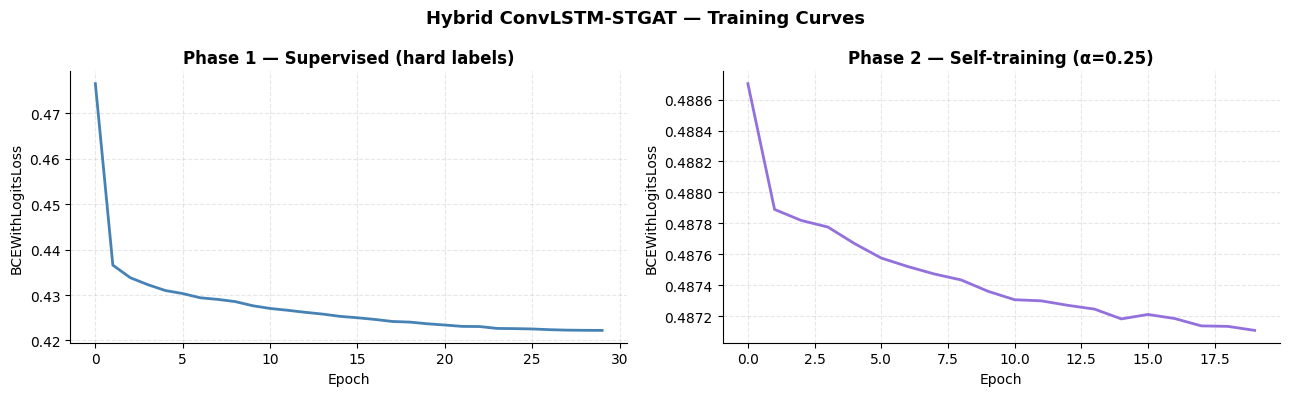

In [14]:
ALPHA      = 0.25   # mixing coefficient — tune between 0.1 and 0.4
EPOCHS_P2  = 20    # additional epochs for self-training

print(f'Phase 2 — Autoregressive self-training  (α={ALPHA}, {EPOCHS_P2} epochs)')
print()

# ── Step 1: Collect Phase-1 soft predictions on the training set ──────────────
print('Collecting Phase-1 training-set predictions...')

# Build a DataLoader over training set WITHOUT shuffling for alignment
train_ref_dl = DataLoader(train_ds, batch_size=4, shuffle=False,
                          num_workers=2, pin_memory=True)

hybrid.eval()
p1_proba_list = []
with torch.no_grad():
    for xb, _ in train_ref_dl:
        logits = hybrid(xb.to(DEVICE), edge_index_dev)
        p1_proba_list.append(torch.sigmoid(logits).cpu().numpy())   # (B, N)

p1_proba_all = np.concatenate(p1_proba_list, axis=0)  # (n_train_samples, N)
print(f'  Phase-1 proba array : {p1_proba_all.shape}')
print(f'  Mean predicted prob : {p1_proba_all.mean():.4f}')
print(f'  Max  predicted prob : {p1_proba_all.max():.4f}')

# ── Self-training dataset with soft targets ───────────────────────────────────
class SelfTrainDataset(Dataset):
    """
    Wraps CrimeGraphDataset but overrides the label with a mix of
    the original hard binary label and the Phase-1 model's soft prediction.
    """
    def __init__(self, base_ds, soft_proba, alpha=0.25):
        self.base  = base_ds
        self.soft  = soft_proba   # (n_samples, N)
        self.alpha = alpha

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x, y_hard = self.base[idx]           # y_hard: (N,) binary
        y_soft    = torch.tensor(self.soft[idx], dtype=torch.float32)
        y_mixed   = (1 - self.alpha) * y_hard + self.alpha * y_soft
        return x, y_mixed

st_ds = SelfTrainDataset(train_ds, p1_proba_all, alpha=ALPHA)
st_dl = DataLoader(st_ds, batch_size=4, shuffle=True, num_workers=2, pin_memory=True)

print()
print(f'Self-training dataset size  : {len(st_ds)} samples')
print(f'Mean mixed-label value      : {p1_proba_all.mean() * ALPHA + flat_labels[:len(p1_proba_all)*N].reshape(len(p1_proba_all), N).mean() * (1 - ALPHA):.4f}')

# ── Step 2: Phase-2 training with soft targets ────────────────────────────────
# Use MSE loss on soft targets (equivalent to KL div for Bernoulli with soft labels)
# Alternatively BCEWithLogitsLoss still works — logits vs soft labels in [0,1]
optimizer_p2 = torch.optim.AdamW(hybrid.parameters(), lr=2e-4, weight_decay=1e-4)
scheduler_p2 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_p2, T_max=EPOCHS_P2, eta_min=1e-6)

# BCEWithLogitsLoss works with soft labels — y_mixed ∈ [0, 1]
criterion_p2 = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

p2_losses = []

for epoch in range(1, EPOCHS_P2 + 1):
    hybrid.train()
    epoch_loss = 0.0
    for xb, yb_mixed in st_dl:
        xb, yb_mixed = xb.to(DEVICE), yb_mixed.to(DEVICE)
        optimizer_p2.zero_grad()
        logits = hybrid(xb, edge_index_dev)
        loss   = criterion_p2(logits, yb_mixed)
        loss.backward()
        nn.utils.clip_grad_norm_(hybrid.parameters(), max_norm=1.0)
        optimizer_p2.step()
        epoch_loss += loss.item()

    avg = epoch_loss / len(st_dl)
    p2_losses.append(avg)
    scheduler_p2.step()

    if epoch % 5 == 0:
        print(f'  Epoch P2-{epoch:02d}/{EPOCHS_P2}  loss={avg:.4f}  '
              f'lr={optimizer_p2.param_groups[0]["lr"]:.2e}')

# Save final model
torch.save(hybrid.state_dict(), f'{MODEL_DIR}/hybrid_convlstm_stgat.pt')
print()
print('✅ Phase 2 training complete — final model saved')

# ── Plot both training curves ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Hybrid ConvLSTM-STGAT — Training Curves', fontsize=13, fontweight='bold')

axes[0].plot(p1_losses, color='steelblue', linewidth=2)
axes[0].set_title('Phase 1 — Supervised (hard labels)', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCEWithLogitsLoss')
axes[0].grid(alpha=0.3, linestyle='--')
axes[0].spines[['top','right']].set_visible(False)

axes[1].plot(p2_losses, color='mediumpurple', linewidth=2)
axes[1].set_title(f'Phase 2 — Self-training (α={ALPHA})', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('BCEWithLogitsLoss')
axes[1].grid(alpha=0.3, linestyle='--')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/chicago/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 🔬 STEP 9 — Chicago Inference & Raw Evaluation

In [15]:
def run_inference(model, loader, apply_sigmoid=True):
    """Run model over a DataLoader, return flat (preds, trues) arrays."""
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in loader:
            logits = model(xb.to(DEVICE), edge_index_dev)
            out    = torch.sigmoid(logits) if apply_sigmoid else logits
            preds.append(out.cpu().numpy())
            trues.append(yb.numpy())
    return np.concatenate(preds).ravel(), np.concatenate(trues).ravel()

# ── Raw test probabilities ─────────────────────────────────────────────────────
y_test_p, y_test_t      = run_inference(hybrid, test_dl, apply_sigmoid=True)
y_test_logits, _        = run_inference(hybrid, test_dl, apply_sigmoid=False)

metrics_raw = compute_metrics(y_test_t, y_test_p, threshold=0.5)
print('===== Chicago — Hybrid Raw (threshold=0.5) =====')
for k, v in metrics_raw.items():
    print(f'  {k:<12}: {v}')

pcts = np.percentile(y_test_logits, [50, 90, 95, 99, 99.9])
print(f'\nLogit percentiles [50,90,95,99,99.9]: {np.round(pcts, 3)}')
print('\n✅ Raw inference done')


===== Chicago — Hybrid Raw (threshold=0.5) =====
  Accuracy    : 0.7853
  AUROC       : 0.9296
  AUPRC       : 0.4122
  F1          : 0.3543
  Precision   : 0.2166
  Recall      : 0.9726
  PAI@50      : 15.1867
  PAI@100     : 15.5168
  PAI@200     : 15.3518

Logit percentiles [50,90,95,99,99.9]: [-8.159  1.549  1.988  2.69   3.775]

✅ Raw inference done


## 🎯 STEP 10 — Chicago Calibration (Temperature + Platt)

In [16]:
# ── Calibration set logits ────────────────────────────────────────────────────
y_cal_logits, y_cal_t = run_inference(hybrid, cal_dl, apply_sigmoid=False)

print('── Step 1: Temperature Scaling ──')
T_opt, y_cal_ts = find_temperature(y_cal_logits, y_cal_t)
print(f'  Optimal T = {T_opt:.4f}')
y_test_ts = scipy_expit(y_test_logits / T_opt)

print('\n── Step 2: Platt Scaling ──')
y_test_cal, best_t, platt_chi = platt_calibrate(y_cal_ts, y_cal_t, y_test_ts)
print(f'  F1-optimal threshold = {best_t:.4f}')

metrics_ts  = compute_metrics(y_test_t, y_test_ts,  threshold=0.5)
metrics_cal = compute_metrics(y_test_t, y_test_cal, threshold=best_t)

print('\n===== Chicago — Temp-Scaled (t=0.5) =====')
for k, v in metrics_ts.items():  print(f'  {k:<12}: {v}')

print(f'\n===== Chicago — Calibrated (t={best_t:.4f}) =====')
for k, v in metrics_cal.items(): print(f'  {k:<12}: {v}')

# Save calibration artefacts
joblib.dump(platt_chi, f'{CAL_DIR}/chicago_platt_scaler.pkl')
np.save(f'{CAL_DIR}/chicago_proba_raw.npy',  y_test_p)
np.save(f'{CAL_DIR}/chicago_proba_ts.npy',   y_test_ts)
np.save(f'{CAL_DIR}/chicago_proba_cal.npy',  y_test_cal)
np.save(f'{CAL_DIR}/chicago_true.npy',       y_test_t)
with open(f'{CAL_DIR}/chicago_meta.json', 'w') as f:
    json.dump({'T_opt': float(T_opt), 'best_threshold': float(best_t)}, f, indent=2)
print('\n✅ Calibration artefacts saved')


── Step 1: Temperature Scaling ──
  Optimal T = 2.3126

── Step 2: Platt Scaling ──
  F1-optimal threshold = 0.2222

===== Chicago — Temp-Scaled (t=0.5) =====
  Accuracy    : 0.7853
  AUROC       : 0.9296
  AUPRC       : 0.4122
  F1          : 0.3543
  Precision   : 0.2166
  Recall      : 0.9726
  PAI@50      : 15.1867
  PAI@100     : 15.5168
  PAI@200     : 15.3518

===== Chicago — Calibrated (t=0.2222) =====
  Accuracy    : 0.9103
  AUROC       : 0.9296
  AUPRC       : 0.4122
  F1          : 0.4489
  Precision   : 0.3576
  Recall      : 0.6027
  PAI@50      : 15.1867
  PAI@100     : 15.5168
  PAI@200     : 15.3518

✅ Calibration artefacts saved


## 📊 STEP 11 — Chicago Results Tables & Plots

===== Chicago — Hybrid Calibration Comparison =====
                       AUROC   AUPRC      F1  Precision  Recall   PAI@50  PAI@100  PAI@200
Configuration                                                                             
Raw (t=0.5)           0.9296  0.4122  0.3543     0.2166  0.9726  15.1867  15.5168  15.3518
Temp-Scaled (t=0.5)   0.9296  0.4122  0.3543     0.2166  0.9726  15.1867  15.5168  15.3518
Calibrated (t=0.222)  0.9296  0.4122  0.4489     0.3576  0.6027  15.1867  15.5168  15.3518


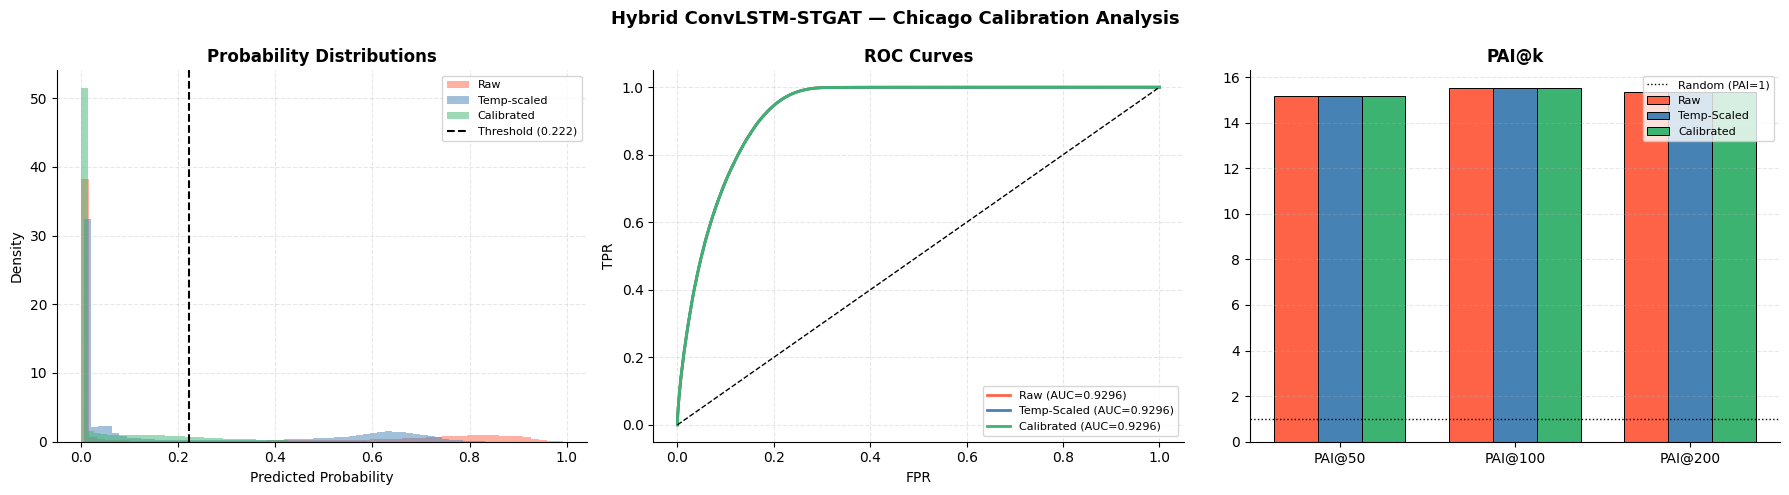

✅ Chicago plots saved


In [17]:
SHOW_COLS = ['AUROC','AUPRC','F1','Precision','Recall','PAI@50','PAI@100','PAI@200']

chi_df = pd.DataFrame({
    'Raw (t=0.5)'             : metrics_raw,
    'Temp-Scaled (t=0.5)'    : metrics_ts,
    f'Calibrated (t={best_t:.3f})': metrics_cal,
}).T[SHOW_COLS]
chi_df.index.name = 'Configuration'

print('===== Chicago — Hybrid Calibration Comparison =====')
print(chi_df.to_string())
chi_df.to_csv(f'{OUT_DIR}/tables/chicago_calibration_comparison.csv')

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Hybrid ConvLSTM-STGAT — Chicago Calibration Analysis',
             fontsize=13, fontweight='bold')

colors = {'Raw': 'tomato', 'Temp': 'steelblue', 'Cal': 'mediumseagreen'}

# Panel 1: prob distributions
ax = axes[0]
for arr, label, c in [
    (y_test_p,   'Raw',          colors['Raw']),
    (y_test_ts,  'Temp-scaled',  colors['Temp']),
    (y_test_cal, 'Calibrated',   colors['Cal']),
]:
    ax.hist(arr, bins=60, alpha=0.5, color=c, label=label, density=True)
ax.axvline(best_t, color='black', linestyle='--', linewidth=1.5,
           label=f'Threshold ({best_t:.3f})')
ax.set_xlabel('Predicted Probability'); ax.set_ylabel('Density')
ax.set_title('Probability Distributions', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3, linestyle='--')
ax.spines[['top','right']].set_visible(False)

# Panel 2: ROC curves
ax = axes[1]
for arr, label, c in [
    (y_test_p,   'Raw',         colors['Raw']),
    (y_test_ts,  'Temp-Scaled', colors['Temp']),
    (y_test_cal, 'Calibrated',  colors['Cal']),
]:
    fpr, tpr, _ = roc_curve(y_test_t, arr)
    auc = roc_auc_score(y_test_t, arr)
    ax.plot(fpr, tpr, color=c, linewidth=2, label=f'{label} (AUC={auc:.4f})')
ax.plot([0,1],[0,1],'k--',linewidth=1)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curves', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3, linestyle='--')
ax.spines[['top','right']].set_visible(False)

# Panel 3: PAI@k
ax = axes[2]
k_vals = [50, 100, 200]; x_ = np.arange(len(k_vals)); w = 0.25
for i, (arr, label, c) in enumerate([
    (y_test_p,   'Raw',         colors['Raw']),
    (y_test_ts,  'Temp-Scaled', colors['Temp']),
    (y_test_cal, 'Calibrated',  colors['Cal']),
]):
    pai = [compute_pai(y_test_t, arr, k) for k in k_vals]
    ax.bar(x_ + (i-1)*w, pai, w, label=label, color=c, edgecolor='black', lw=0.7)
ax.axhline(1.0, color='black', linestyle=':', linewidth=1, label='Random (PAI=1)')
ax.set_xticks(x_); ax.set_xticklabels([f'PAI@{k}' for k in k_vals])
ax.set_title('PAI@k', fontweight='bold')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/chicago/calibration_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chicago plots saved')


## 🌆 STEP 12 — LA Cross-City: Preprocessing & Graph

In [18]:
LA_FILE = f'{BASE_DIR}/data/raw/la_crimes.csv'

if not os.path.exists(LA_FILE):
    print('⚠️  la_crimes.csv not found — cross-city section will be skipped')
    HAS_LA = False
else:
    la_raw = pd.read_csv(LA_FILE, low_memory=False)
    print(f'LA raw shape: {la_raw.shape}')
    HAS_LA = True

if HAS_LA:
    la = la_raw.copy()
    la.columns = [c.strip().lower().replace(' ', '_') for c in la.columns]

    date_col       = 'date_occ' if 'date_occ' in la.columns else 'date_rptd'
    la['date']     = pd.to_datetime(la[date_col], infer_datetime_format=True, errors='coerce')
    la['latitude'] = pd.to_numeric(la.get('lat',  la.get('location_1')), errors='coerce')
    la['longitude']= pd.to_numeric(la.get('lon',  la.get('location_1')), errors='coerce')
    la.dropna(subset=['date','latitude','longitude'], inplace=True)
    la = la[(la['latitude'].between(33.7, 34.35)) &
            (la['longitude'].between(-118.65, -118.15))]

    la['grid_row']  = ((la['latitude']  - 33.70)    / CELL_SIZE).astype(int)
    la['grid_col']  = ((la['longitude'] - (-118.65)) / CELL_SIZE).astype(int)
    la['date_only'] = la['date'].dt.date

    la_gr_max = int(la['grid_row'].clip(lower=0).max()) + 1
    la_gc_max = int(la['grid_col'].clip(lower=0).max()) + 1
    la_counts = la.groupby(['date_only','grid_row','grid_col']).size().reset_index(name='cnt')
    la_dates  = pd.date_range(la['date'].min().date(), la['date'].max().date(), freq='D')
    la_di     = {d.date(): i for i, d in enumerate(la_dates)}
    la_grid   = np.zeros((len(la_dates), la_gr_max, la_gc_max), dtype=np.float32)

    for _, row in la_counts.iterrows():
        d_i = la_di.get(row['date_only'])
        r, c = int(row['grid_row']), int(row['grid_col'])
        if d_i is not None and 0 <= r < la_gr_max and 0 <= c < la_gc_max:
            la_grid[d_i, r, c] = row['cnt']

    la_T         = la_grid.shape[0]
    la_cal_split = int(la_T * 0.70)
    la_split     = int(la_T * 0.80)
    la_H, la_W   = la_gr_max, la_gc_max
    la_N         = la_H * la_W

    la_edge_index     = build_queen_graph(la_H, la_W)
    la_edge_index_dev = la_edge_index.to(DEVICE)

    LA_POI_PATH = f'{PROC_DIR}/la_poi_per_cell.csv'
    if os.path.exists(LA_POI_PATH):
        la_poi = pd.read_csv(LA_POI_PATH)
        la_poi_grid = np.zeros((la_H, la_W, len(STATIC_COLS)), dtype=np.float32)
        for _, row in la_poi.iterrows():
            r, c = int(row.get('grid_row', 0)), int(row.get('grid_col', 0))
            if 0 <= r < la_H and 0 <= c < la_W:
                for fi, col in enumerate(STATIC_COLS):
                    if col in row: la_poi_grid[r, c, fi] = row[col]
        la_node_features = la_poi_grid.reshape(la_N, len(STATIC_COLS)).astype(np.float32)
        la_node_features = np.clip(
            (la_node_features - poi_min.values) / (poi_max.values - poi_min.values + 1e-9), 0, 1)
        print('✅ LA POI features loaded')
    else:
        la_node_features = np.zeros((la_N, len(STATIC_COLS)), dtype=np.float32)
        print('⚠️  LA POI not found — using zero static features')

    la_cal_ds  = CrimeGraphDataset(la_grid[la_cal_split:la_split], SEQ_LEN, la_node_features)
    la_test_ds = CrimeGraphDataset(la_grid[la_split:],             SEQ_LEN, la_node_features)
    la_cal_dl  = DataLoader(la_cal_ds,  batch_size=4, shuffle=False, num_workers=2)
    la_test_dl = DataLoader(la_test_ds, batch_size=4, shuffle=False, num_workers=2)

    print(f'LA grid : {la_grid.shape}  |  nodes: {la_N}  |  edges: {la_edge_index.shape[1]}')
    print(f'LA cal  : {len(la_cal_ds)} samples')
    print(f'LA test : {len(la_test_ds)} samples')
    print('✅ LA preprocessing done')


LA raw shape: (200000, 28)
✅ LA POI features loaded
LA grid : (367, 126, 99)  |  nodes: 12474  |  edges: 98446
LA cal  : 30 samples
LA test : 67 samples
✅ LA preprocessing done


## 🌆 STEP 13 — LA Inference: Temperature + Platt Calibration

In [22]:
if not HAS_LA:
    print('⚠️  Skipping — no LA data')
else:
    def run_la_inference(model, loader, la_ei_dev, apply_sigmoid=True):
        """Run hybrid model on an LA-sized DataLoader using LA's edge index."""
        model.eval()
        preds, trues = [], []
        with torch.no_grad():
            for xb, yb in loader:
                xb = xb.to(DEVICE).float()
                # Forward pass with LA's graph topology
                logits = model(xb, la_ei_dev)
                out    = torch.sigmoid(logits) if apply_sigmoid else logits
                preds.append(out.cpu().numpy())
                trues.append(yb.numpy())
        return np.concatenate(preds).ravel(), np.concatenate(trues).ravel()

    # Store original grid dimensions
    original_grid_h = hybrid.grid_h
    original_grid_w = hybrid.grid_w

    # Temporarily update model's grid dimensions for LA inference
    hybrid.grid_h = la_H
    hybrid.grid_w = la_W

    # ── LA calibration ────────────────────────────────────────────────────────
    la_cal_logits, la_cal_t = run_la_inference(hybrid, la_cal_dl, la_edge_index_dev, apply_sigmoid=False)
    la_test_p, la_test_t   = run_la_inference(hybrid, la_test_dl, la_edge_index_dev, apply_sigmoid=True)
    la_test_logits, _       = run_la_inference(hybrid, la_test_dl, la_edge_index_dev, apply_sigmoid=False)

    # Restore original grid dimensions after LA inference
    hybrid.grid_h = original_grid_h
    hybrid.grid_w = original_grid_w

    print('── LA Temperature Scaling ──')
    la_T_opt, la_cal_ts    = find_temperature(la_cal_logits, la_cal_t)
    la_test_ts             = scipy_expit(la_test_logits / la_T_opt)
    print(f'  T_opt = {la_T_opt:.4f}')

    print('\n── LA Platt Scaling ──')
    la_test_cal, la_best_t, platt_la = platt_calibrate(la_cal_ts, la_cal_t, la_test_ts)
    print(f'  F1-optimal threshold = {la_best_t:.4f}')

    la_metrics_raw = compute_metrics(la_test_t, la_test_p,   threshold=0.5)
    la_metrics_ts  = compute_metrics(la_test_t, la_test_ts,  threshold=0.5)
    la_metrics_cal = compute_metrics(la_test_t, la_test_cal, threshold=la_best_t)

    print('\n===== LA — Raw (t=0.5) =====')
    for k, v in la_metrics_raw.items(): print(f'  {k:<12}: {v}')

    print(f'\n===== LA — Calibrated (t={la_best_t:.4f}) =====')
    for k, v in la_metrics_cal.items(): print(f'  {k:<12}: {v}')

    # Save LA artefacts
    joblib.dump(platt_la, f'{CAL_DIR}/la_platt_scaler.pkl')
    np.save(f'{CAL_DIR}/la_proba_cal.npy', la_test_cal)
    np.save(f'{CAL_DIR}/la_true.npy',      la_test_t)
    with open(f'{CAL_DIR}/la_meta.json', 'w') as f:
        json.dump({'T_opt': float(la_T_opt), 'best_threshold': float(la_best_t)}, f, indent=2)
    print('\n✅ LA calibration artefacts saved')

── LA Temperature Scaling ──
  T_opt = 2.0260

── LA Platt Scaling ──
  F1-optimal threshold = 0.0559

===== LA — Raw (t=0.5) =====
  Accuracy    : 0.9663
  AUROC       : 0.8634
  AUPRC       : 0.1674
  F1          : 0.0129
  Precision   : 0.2314
  Recall      : 0.0066
  PAI@50      : 10.8614
  PAI@100     : 10.258
  PAI@200     : 8.1461

===== LA — Calibrated (t=0.0559) =====
  Accuracy    : 0.9228
  AUROC       : 0.8634
  AUPRC       : 0.1674
  F1          : 0.2626
  Precision   : 0.1922
  Recall      : 0.4145
  PAI@50      : 10.8614
  PAI@100     : 10.258
  PAI@200     : 8.1461

✅ LA calibration artefacts saved


## 📊 STEP 14 — Cross-City Results Table & Plot

===== LA — Cross-City Zero-Shot Transfer =====
                          AUROC   AUPRC      F1  Precision  Recall   PAI@50  PAI@100  PAI@200
Configuration                                                                                
LA Raw (t=0.5)           0.8634  0.1674  0.0129     0.2314  0.0066  10.8614   10.258   8.1461
LA Temp-Scaled (t=0.5)   0.8634  0.1674  0.0129     0.2314  0.0066  10.8614   10.258   8.1461
LA Calibrated (t=0.056)  0.8634  0.1674  0.2626     0.1922  0.4145  10.8614   10.258   8.1461


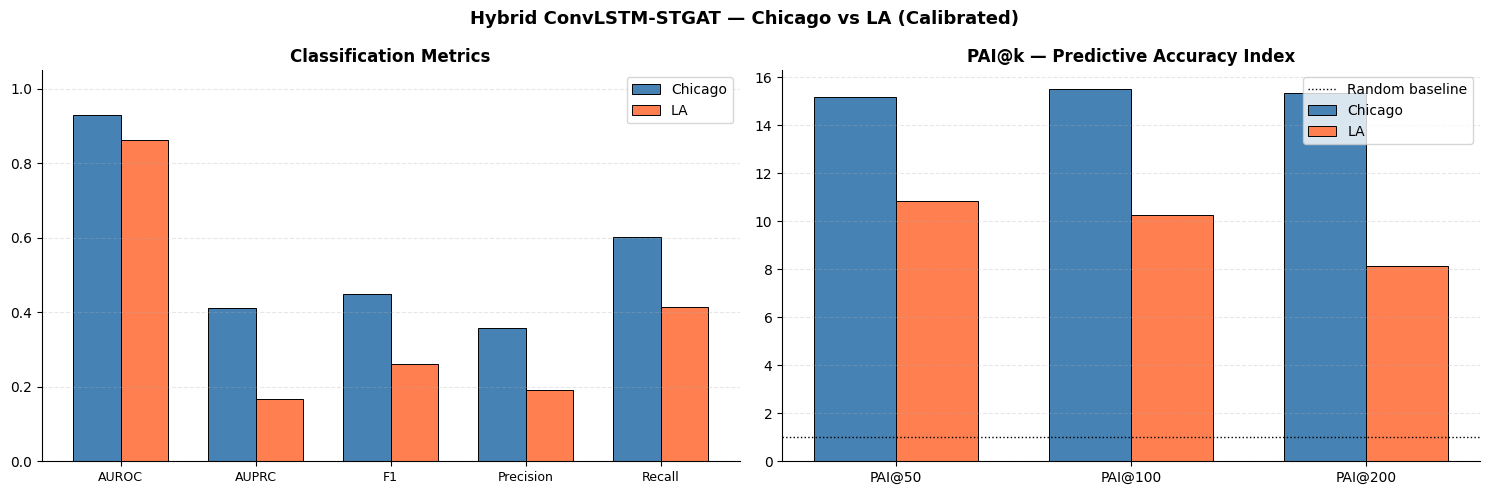

✅ Cross-city plots saved


In [23]:
if HAS_LA:
    la_df = pd.DataFrame({
        'LA Raw (t=0.5)'               : la_metrics_raw,
        'LA Temp-Scaled (t=0.5)'       : la_metrics_ts,
        f'LA Calibrated (t={la_best_t:.3f})': la_metrics_cal,
    }).T[SHOW_COLS]
    la_df.index.name = 'Configuration'

    print('===== LA — Cross-City Zero-Shot Transfer =====')
    print(la_df.to_string())
    la_df.to_csv(f'{OUT_DIR}/tables/la_calibration_comparison.csv')

    # ── Combined Chicago vs LA bar plot ───────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle('Hybrid ConvLSTM-STGAT — Chicago vs LA (Calibrated)',
                 fontsize=13, fontweight='bold')

    metrics_to_plot = ['AUROC','AUPRC','F1','Precision','Recall']
    chi_vals = [metrics_cal[m]    for m in metrics_to_plot]
    la_vals  = [la_metrics_cal[m] for m in metrics_to_plot]
    x_       = np.arange(len(metrics_to_plot)); w = 0.35

    ax = axes[0]
    ax.bar(x_ - w/2, chi_vals, w, label='Chicago', color='steelblue', edgecolor='black', lw=0.7)
    ax.bar(x_ + w/2, la_vals,  w, label='LA',      color='coral',     edgecolor='black', lw=0.7)
    ax.set_xticks(x_); ax.set_xticklabels(metrics_to_plot, fontsize=9)
    ax.set_ylim(0, 1.05); ax.set_title('Classification Metrics', fontweight='bold')
    ax.legend(); ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines[['top','right']].set_visible(False)

    ax = axes[1]
    k_vals   = [50, 100, 200]; xk = np.arange(len(k_vals))
    chi_pai  = [metrics_cal[f'PAI@{k}']    for k in k_vals]
    la_pai   = [la_metrics_cal[f'PAI@{k}'] for k in k_vals]
    ax.bar(xk - w/2, chi_pai, w, label='Chicago', color='steelblue', edgecolor='black', lw=0.7)
    ax.bar(xk + w/2, la_pai,  w, label='LA',      color='coral',     edgecolor='black', lw=0.7)
    ax.axhline(1.0, color='black', linestyle=':', linewidth=1, label='Random baseline')
    ax.set_xticks(xk); ax.set_xticklabels([f'PAI@{k}' for k in k_vals])
    ax.set_title('PAI@k — Predictive Accuracy Index', fontweight='bold')
    ax.legend(); ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines[['top','right']].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/crosscity/chicago_vs_la.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Cross-city plots saved')


## 📋 STEP 15 — Full Summary Table (All Configurations)

In [25]:
# ── Consolidated summary ─────────────────────────────────────────────────────
rows = {
    'Chicago — Raw'       : metrics_raw,
    'Chicago — Temp-Scaled': metrics_ts,
    'Chicago — Calibrated' : metrics_cal,
}
if HAS_LA:
    rows['LA — Raw']        = la_metrics_raw
    rows['LA — Temp-Scaled']= la_metrics_ts
    rows['LA — Calibrated'] = la_metrics_cal

summary_df = pd.DataFrame(rows).T[SHOW_COLS]
summary_df.index.name = 'Model / City'

print('\n' + '='*70)
print('  HYBRID ConvLSTM-STGAT — FULL RESULTS SUMMARY')
print('='*70)
print(summary_df.to_string())
summary_df.to_csv(f'{OUT_DIR}/tables/full_summary.csv')
print()
print(f'📁 All outputs saved to {OUT_DIR}')
print('✅ Done!')

# ── Phase-1 vs Phase-2 delta (shows self-training benefit) ─────────────────
print()
print('── Self-Training Improvement (Phase 2 − Phase 1) ──')
print('   Loading Phase-1 checkpoint for comparison...')
hybrid_p1 = HybridConvLSTMSTGAT(
    in_ch=IN_CH, conv_hid=16, gat_hid=16,  # These parameters must match the saved model
    gat_heads=2, fused_dim=32, gru_hid=32, # These parameters must match the saved model
    dropout=0.1, grid_h=H, grid_w=W        # Include grid_h and grid_w for consistency
).to(DEVICE)
hybrid_p1.load_state_dict(torch.load(f'{MODEL_DIR}/hybrid_phase1.pt', map_location=DEVICE))
hybrid_p1.eval()

y_p1_proba, _ = run_inference(hybrid_p1, test_dl, apply_sigmoid=True)
m_p1          = compute_metrics(y_test_t, y_p1_proba, threshold=0.5)
m_p2          = metrics_raw   # Phase-2 model raw (before calibration)

print(f'  {"Metric":<12}  {"Phase1":>8}  {"Phase2":>8}  {"Delta":>8}')
for k in SHOW_COLS:
    delta = m_p2[k] - m_p1[k]
    sign  = '+' if delta >= 0 else ''
    print(f'  {k:<12}  {m_p1[k]:>8.4f}  {m_p2[k]:>8.4f}  {sign}{delta:>7.4f}')



  HYBRID ConvLSTM-STGAT — FULL RESULTS SUMMARY
                        AUROC   AUPRC      F1  Precision  Recall   PAI@50  PAI@100  PAI@200
Model / City                                                                               
Chicago — Raw          0.9296  0.4122  0.3543     0.2166  0.9726  15.1867  15.5168  15.3518
Chicago — Temp-Scaled  0.9296  0.4122  0.3543     0.2166  0.9726  15.1867  15.5168  15.3518
Chicago — Calibrated   0.9296  0.4122  0.4489     0.3576  0.6027  15.1867  15.5168  15.3518
LA — Raw               0.8634  0.1674  0.0129     0.2314  0.0066  10.8614  10.2580   8.1461
LA — Temp-Scaled       0.8634  0.1674  0.0129     0.2314  0.0066  10.8614  10.2580   8.1461
LA — Calibrated        0.8634  0.1674  0.2626     0.1922  0.4145  10.8614  10.2580   8.1461

📁 All outputs saved to /content/drive/MyDrive/CrimeHotspot/outputs/hybrid
✅ Done!

── Self-Training Improvement (Phase 2 − Phase 1) ──
   Loading Phase-1 checkpoint for comparison...
  Metric          Phase1    Phas